In [1]:
from calendar import error

import pandas as pd
import numpy as np
from django.db.backends.dummy.base import ignore
from pandas import pivot_table



In [2]:
data = pd.read_csv("./educ_figdp_1_Data.csv", na_values=":", usecols=["TIME","GEO","Value"])


In [3]:
print(data)

     TIME                            GEO  Value
0    2000  European Union (28 countries)    NaN
1    2001  European Union (28 countries)    NaN
2    2002  European Union (28 countries)   5.00
3    2003  European Union (28 countries)   5.03
4    2004  European Union (28 countries)   4.95
..    ...                            ...    ...
379  2007                        Finland   5.90
380  2008                        Finland   6.10
381  2009                        Finland   6.81
382  2010                        Finland   6.85
383  2011                        Finland   6.76

[384 rows x 3 columns]


In [4]:
# The head method returns the first 5 rows
print(data.head())


   TIME                            GEO  Value
0  2000  European Union (28 countries)    NaN
1  2001  European Union (28 countries)    NaN
2  2002  European Union (28 countries)   5.00
3  2003  European Union (28 countries)   5.03
4  2004  European Union (28 countries)   4.95


In [5]:
# The tail methods returns the last 5 rows
print(data.tail())

     TIME      GEO  Value
379  2007  Finland   5.90
380  2008  Finland   6.10
381  2009  Finland   6.81
382  2010  Finland   6.85
383  2011  Finland   6.76


In [6]:
# To get statistical information for all column in our DataFrame
print(data.describe())

              TIME       Value
count   384.000000  361.000000
mean   2005.500000    5.203989
std       3.456556    1.021694
min    2000.000000    2.880000
25%    2002.750000    4.620000
50%    2005.500000    5.060000
75%    2008.250000    5.660000
max    2011.000000    8.810000


In [7]:
# We can select the subset of our data
print(data['Value'])

0       NaN
1       NaN
2      5.00
3      5.03
4      4.95
       ... 
379    5.90
380    6.10
381    6.81
382    6.85
383    6.76
Name: Value, Length: 384, dtype: float64


In [8]:
# Slicing
# If we want to select a subset of rows from a DataFrame, we can do so by indicating
# a range of rows separated by a colon (:) inside the square brackets.

print(data[10:15])

    TIME                            GEO  Value
10  2010  European Union (28 countries)   5.41
11  2011  European Union (28 countries)   5.25
12  2000  European Union (27 countries)   4.91
13  2001  European Union (27 countries)   4.99
14  2002  European Union (27 countries)   5.00


In [9]:
# If we want to select a subset of columns and rows using the labels as our
# references instead of the positions, we can use ixindexing:

print(data[90:95], ['TIME', 'GEO'])

    TIME      GEO  Value
90  2006  Belgium   5.98
91  2007  Belgium   6.00
92  2008  Belgium   6.43
93  2009  Belgium   6.57
94  2010  Belgium   6.58 ['TIME', 'GEO']


In [10]:
# Boolean Indexing
# Another way to select a subset of data is by applying Boolean indexing. This indexing is commonly known as a filter.
# Boolean indexing for geater than
data [data['Value'] > 6.5].tail()


,TIME,GEO,Value
286,2010,Malta,6.74
287,2011,Malta,7.96
381,2009,Finland,6.81
382,2010,Finland,6.85
383,2011,Finland,6.76


In [11]:
# Boolean indexing for less than
data [data['Value'] < 6.5].tail()

,TIME,GEO,Value
376,2004,Finland,6.42
377,2005,Finland,6.30
378,2006,Finland,6.18
379,2007,Finland,5.90
380,2008,Finland,6.10


In [12]:
# Boolean indexing for greater than or equal
data[data['Value'] >= 6.5].tail()

,TIME,GEO,Value
286,2010,Malta,6.74
287,2011,Malta,7.96
381,2009,Finland,6.81
382,2010,Finland,6.85
383,2011,Finland,6.76


In [18]:
# Boolean indexing for less than or equal to
data[data['Value'] <= 6.5].tail()

,TIME,GEO,Value
376,2004,Finland,6.42
377,2005,Finland,6.30
378,2006,Finland,6.18
379,2007,Finland,5.90
380,2008,Finland,6.10


In [22]:
# Boolean indexing for equal to
data[data['Value'] == 6.18].tail()

,TIME,GEO,Value
283,2007,Malta,6.18
378,2006,Finland,6.18


In [23]:
# Boolean indexing for not equal to
data[data['Value'] != 6.5].head()

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
2,2002,European Union (28 countries),5.00
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95


In [24]:
# Aggregate function
# func(), count(), sun(), min(), median(), max(), prod(), std(), var(), mean()


In [27]:
# isnull() function is used to filter rows that have missing value
data[data['Value'].isnull() ].head()

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
36,2000,Euro area (18 countries),NaN
37,2001,Euro area (18 countries),NaN
48,2000,Euro area (17 countries),NaN


In [13]:
data .max (axis = 0)

TIME      2011
GEO      Spain
Value     8.81
dtype: object

In [14]:
# Pandas maximum function
maximum =  "Pandas max function:",  data['Value'].max()


<built-in function max>


In [15]:
print(maximum)

('Pandas max function:', np.float64(8.81))


In [16]:
# Python maximum function
python_max = "python max function:",  max(data['Value'])

In [17]:
print(python_max)

('python max function:', nan)


In [18]:
#  we can apply operations over all the values in rows, columns or a selection of both
#  For example we can apply any binary arithmetical operation (+,-,*,/) to an entire row:

division = data['Value'] / 100
division.head()

0       NaN
1       NaN
2    0.0500
3    0.0503
4    0.0495
Name: Value, dtype: float64

In [19]:
# we can apply any function to a DataFrame or Series just setting its name as argument of the
#apply method. For example, in the following code, we apply the sqrt function from the NumPy library to
#perform the square root of each value in the Value column.

square_root = data['Value'].apply(np.sqrt)
square_root.head()

0         NaN
1         NaN
2    2.236068
3    2.242766
4    2.224860
Name: Value, dtype: float64

In [21]:
# If we need to design a specific function to apply it, we can write an in-line function, commonly known as
#a λ-function. A λ-function is a function without a name. It is only necessary to specify the parameters it
#receives, between the lambda keyword and the colon (:).

lambda_function = data['Value'].apply(lambda d: d**2)
lambda_function.head()

0        NaN
1        NaN
2    25.0000
3    25.3009
4    24.5025
Name: Value, dtype: float64

In [28]:
#Another basic manipulation operation is to set new values in our DataFrame. This can be done directly
#using the assign operator (=) over a DataFrame. For example, to add a new column to a DataFrame, we
#can assign a Series to a selection of a column that does not exist. This will produce a new column in the
#DataFrame after all the others

data['ValueNorm']  = data['Value'] / data['Value'].max()
data.tail()




,TIME,GEO,Value,ValueNorm
379,2007,Finland,5.90,0.669694
380,2008,Finland,6.10,0.692395
381,2009,Finland,6.81,0.772985
382,2010,Finland,6.85,0.777526
383,2011,Finland,6.76,0.767310


In [29]:
#Now, if we want to remove this column from the DataFrame, we can use the drop function; this
#removes the indicated rows if axis=0, or the indicated columns if axis=1. In Pandas, all the functions that
#change the contents of a DataFrame, such as the drop function, will normally return a copy of the
#modified data, instead of overwriting the DataFrame

data.drop('ValueNorm', axis = 1, inplace = True)
data.head()

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
2,2002,European Union (28 countries),5.00
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95


In [31]:
#Instead, if what we want to do is to insert a new row at the bottom of the DataFrame, we can use the
#Pandas append function. This function receives as argument the new row, which is represented as a
#dictionary where the keys are the name of the columns and the values are the associated value. You
#must be aware to setting the ignore_index flag in the append method to True, otherwise the index 0 is
#given to this new row, which will produce an error if it already


new_row = {'TIME': 2000, "Value": 5.00, "GEO": "a"}

data = pd.concat([data, pd.DataFrame(new_row)], ignore_index = True)
data.head()



,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
2,2002,European Union (28 countries),5.0
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95


In [37]:
# if we want to remove this row, we need to use the drop function again.
droping_data = data.drop(data.index[-1])
droping_data.tail()

,TIME,GEO,Value
379,2007,Finland,5.9
380,2008,Finland,6.1
381,2009,Finland,6.81
382,2010,Finland,6.85
383,2011,Finland,6.76


In [43]:
# To remove NaN values, instead of the generic drop function, we can use the
#specificdropna() function. If we want to erase any row that contains an NaN value, we
#have to set the how keyword to any.

dropna_data = data.dropna(how = 'any', subset = ["Value"])
dropna_data.head()


,TIME,GEO,Value
2,2002,European Union (28 countries),5.0
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95
5,2005,European Union (28 countries),4.92
6,2006,European Union (28 countries),4.91


In [45]:
#If, instead of removing the rows containing NaN, we want to fill them with another
#value, then we can use the fillna() method, specifying which value has to be used.

fillna_data = data.fillna(value = {"Value": 0})
fillna_data.head()

,TIME,GEO,Value
0,2000,European Union (28 countries),0
1,2001,European Union (28 countries),0
2,2002,European Union (28 countries),5.0
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95


In [50]:
# Sorting: Another important functionality we will need when inspecting our data is to sort
#bycolumns. We can sort a DataFrame using any column, using the sortfunction.

data['Value'] = pd.to_numeric(data['Value'], errors='coerce')
data.head()

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
2,2002,European Union (28 countries),5.00
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95


In [51]:
# If we want to return to the original order, we can sort by index using sort_index function and specifying axis = 0
data.sort_index(axis = 0, ascending= True, inplace=True)
data.head()

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
2,2002,European Union (28 countries),5.00
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95


In [53]:
# Grouping Data: Another very useful way to inspect data is to group it according to some criteria. For instance, in our
#example it would be nice to group all the data by country, regardless of the year

group = data[["GEO", "Value"]].groupby('GEO').mean()
group.head()

,Value
GEO,
5.0,NaN
Austria,5.618333
Belgium,6.189091
Bulgaria,4.093333
Cyprus,7.023333


In [54]:
# Rearranging data: We can rearrange our data using the
#pivot_table function. Here, we can specify which columns will be the new indexes, the new values, and the new columns.

filtered_data =  data[data["TIME"] > 2005]

pivot_table_data =  pd.pivot_table(filtered_data, values= 'Value', index = ['GEO'], columns=['TIME'])
pivot_table_data.head()

TIME,2006,2007,2008,2009,2010,2011
GEO,,,,,,
Austria,5.40,5.33,5.47,5.98,5.91,5.80
Belgium,5.98,6.00,6.43,6.57,6.58,6.55
Bulgaria,4.04,3.88,4.44,4.58,4.10,3.82
Cyprus,7.02,6.95,7.45,7.98,7.92,7.87
Czech Republic,4.42,4.05,3.92,4.36,4.25,4.51


In [56]:
# We can use new index to select specific rows by label, using the loc operations
pivot_table_data.loc[['Spain', 'Portugal'], [2006, 2011]]

TIME,2006,2011
GEO,,
Spain,4.26,4.82
Portugal,5.07,5.27


In [62]:
# Ranking Data: Another useful visualization feature is to rank data. For example, we would like to know how each
# country is ranked by year. To see this, we will use the pandas rank function

to_drop = [
    'Euro area (13 countries)', 'Euro area(15 countries)',
    'Euro area(17 countries)', 'Euro area(18 countries)',
    'European Union(25 countries)', 'European Union(27 countries)',
    'European Union(28 countries)'
]

pivot_table_data = pivot_table_data.drop(to_drop, axis=0, errors='ignore')
pivot_table_data.head()


TIME,2006,2007,2008,2009,2010,2011
GEO,,,,,,
Austria,5.40,5.33,5.47,5.98,5.91,5.80
Belgium,5.98,6.00,6.43,6.57,6.58,6.55
Bulgaria,4.04,3.88,4.44,4.58,4.10,3.82
Cyprus,7.02,6.95,7.45,7.98,7.92,7.87
Czech Republic,4.42,4.05,3.92,4.36,4.25,4.51


In [67]:
# Global ranking, taking into account all years

total_sum = pivot_table_data.sum(axis = 1).sort_values(ascending = False)
total_sum.rank(ascending =False, method = 'dense').sort_values().head()

GEO
Denmark    1.0
Cyprus     2.0
Finland    3.0
Malta      4.0
Belgium    5.0
dtype: float64

<Axes: title={'center': 'Total Value for Country'}, xlabel='GEO'>

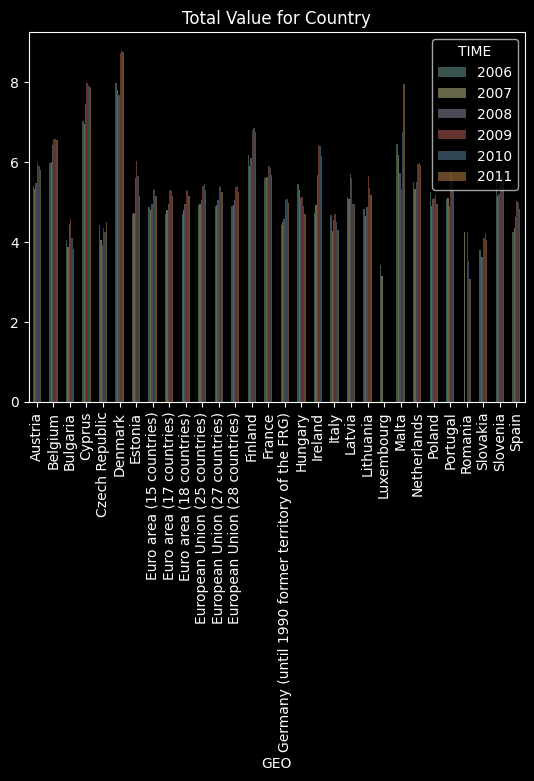

In [68]:
# Plotting: Pandas DataFrames and Series can be plotted using the plot function, which uses the library for graphics Matplotlib
total_sum = pivot_table_data.sum(axis = 1)
pivot_table_data.plot(kind = 'bar', style = 'b', alpha = 0.4, title = "Total Value for Country")

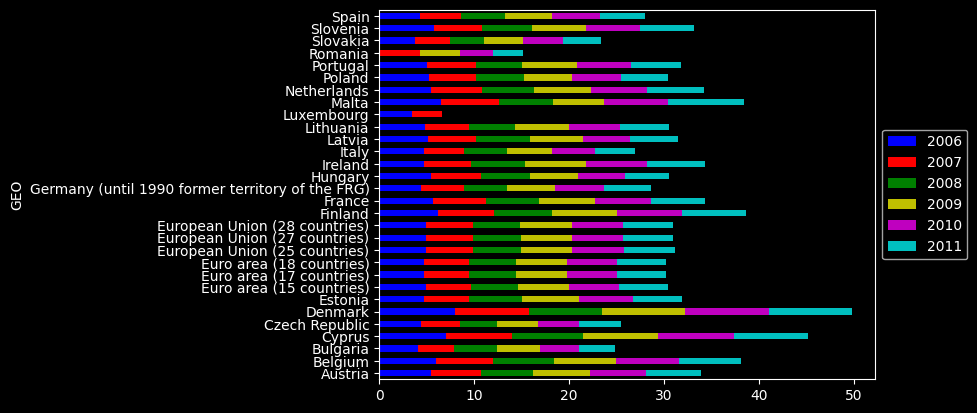

In [70]:
my_color = ['b', 'r', 'g', 'y', 'm', 'c']
axis = pivot_table_data.plot(kind = 'barh', stacked= True, color = my_color)
axis.legend(loc= 'center left', bbox_to_anchor = (1, .5))